## Analisis Explotario de Datos (THE MIMIC)


### 1. Importar librerias

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbn

### 2. Cargas los CSV principales

In [ ]:
admissions = pd.read_csv("admissions.csv")
patients = pd.read_csv("patients.csv")
icustays = pd.read_csv("icustays.csv")
diagnoses_icd = pd.read_csv("diagnoses_icd.csv")
procedures_icd = pd.read_csv("procedures_icd.csv")
labevents = pd.read_csv("labevents.csv")

### 3. Dimensiones de las tablas cargadas

In [ ]:
print("admissions:", admissions.shape)
print("patients:", patients.shape)
print("icustays:", icustays.shape)
print("diagnoses_icd:", diagnoses_icd.shape)
print("procedures_icd:", procedures_icd.shape)
print("labevents:", labevents.shape)

admissions: (275, 16)
patients: (100, 6)
icustays: (140, 8)
diagnoses_icd: (4506, 5)
procedures_icd: (722, 6)
labevents: (107727, 16)


### 4. Vista inicial de las talbas principales

In [ ]:
display(admissions.head())
print(admissions.info())

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
0,10004235,24181354,2196-02-24 14:38:00,2196-03-04 14:02:00,NaN,URGENT,P03YMR,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicaid,ENGLISH,SINGLE,BLACK/CAPE VERDEAN,2196-02-24 12:15:00,2196-02-24 17:07:00,0
1,10009628,25926192,2153-09-17 17:08:00,2153-09-25 13:20:00,NaN,URGENT,P41R5N,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicaid,?,MARRIED,HISPANIC/LATINO - PUERTO RICAN,NaN,NaN,0
2,10018081,23983182,2134-08-18 02:02:00,2134-08-23 19:35:00,NaN,URGENT,P233F6,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicare,ENGLISH,MARRIED,WHITE,2134-08-17 16:24:00,2134-08-18 03:15:00,0
3,10006053,22942076,2111-11-13 23:39:00,2111-11-15 17:20:00,2111-11-15 17:20:00,URGENT,P38TI6,TRANSFER FROM HOSPITAL,DIED,Medicaid,ENGLISH,NaN,UNKNOWN,NaN,NaN,1
4,10031404,21606243,2113-08-04 18:46:00,2113-08-06 20:57:00,NaN,URGENT,P07HDB,TRANSFER FROM HOSPITAL,HOME,Other,ENGLISH,WIDOWED,WHITE,NaN,NaN,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   subject_id            275 non-null    int64 
 1   hadm_id               275 non-null    int64 
 2   admittime             275 non-null    object
 3   dischtime             275 non-null    object
 4   deathtime             15 non-null     object
 5   admission_type        275 non-null    object
 6   admit_provider_id     275 non-null    object
 7   admission_location    275 non-null    object
 8   discharge_location    233 non-null    object
 9   insurance             275 non-null    object
 10  language              275 non-null    object
 11  marital_status        263 non-null    object
 12  race                  275 non-null    object
 13  edregtime             182 non-null    object
 14  edouttime             182 non-null    object
 15  hospital_expire_flag  275 non-null    in

In [ ]:
display(patients.head())
print(patients.info())

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10014729,F,21,2125,2011 - 2013,NaN
1,10003400,F,72,2134,2011 - 2013,2137-09-02
2,10002428,F,80,2155,2011 - 2013,NaN
3,10032725,F,38,2143,2011 - 2013,2143-03-30
4,10027445,F,48,2142,2011 - 2013,2146-02-09


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subject_id         100 non-null    int64 
 1   gender             100 non-null    object
 2   anchor_age         100 non-null    int64 
 3   anchor_year        100 non-null    int64 
 4   anchor_year_group  100 non-null    object
 5   dod                31 non-null     object
dtypes: int64(3), object(3)
memory usage: 4.8+ KB
None


In [ ]:
display(icustays.head())
print(icustays.info())

,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los
0,10018328,23786647,31269608,Neuro Stepdown,Neuro Stepdown,2154-04-24 23:03:44,2154-05-02 15:55:21,7.702512
1,10020187,24104168,37509585,Neuro Surgical Intensive Care Unit (Neuro SICU),Neuro Stepdown,2169-01-15 04:56:00,2169-01-20 15:47:50,5.452662
2,10020187,26842957,32554129,Neuro Intermediate,Neuro Intermediate,2170-02-24 18:18:46,2170-02-25 15:15:26,0.872685
3,10012853,27882036,31338022,Trauma SICU (TSICU),Trauma SICU (TSICU),2176-11-26 02:34:49,2176-11-29 20:58:54,3.766725
4,10020740,25826145,32145159,Trauma SICU (TSICU),Trauma SICU (TSICU),2150-06-03 20:12:32,2150-06-04 21:05:58,1.037106


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   subject_id      140 non-null    int64  
 1   hadm_id         140 non-null    int64  
 2   stay_id         140 non-null    int64  
 3   first_careunit  140 non-null    object 
 4   last_careunit   140 non-null    object 
 5   intime          140 non-null    object 
 6   outtime         140 non-null    object 
 7   los             140 non-null    float64
dtypes: float64(1), int64(3), object(4)
memory usage: 8.9+ KB
None


In [ ]:
display(diagnoses_icd.head())
print(diagnoses_icd.info())

,subject_id,hadm_id,seq_num,icd_code,icd_version
0,10035185,22580999,3,4139,9
1,10035185,22580999,10,V707,9
2,10035185,22580999,1,41401,9
3,10035185,22580999,9,3899,9
4,10035185,22580999,11,V8532,9


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4506 entries, 0 to 4505
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   subject_id   4506 non-null   int64 
 1   hadm_id      4506 non-null   int64 
 2   seq_num      4506 non-null   int64 
 3   icd_code     4506 non-null   object
 4   icd_version  4506 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 176.1+ KB
None


In [ ]:
display(procedures_icd.head())
print(procedures_icd.info())

,subject_id,hadm_id,seq_num,chartdate,icd_code,icd_version
0,10011398,27505812,3,2146-12-15,3961,9
1,10011398,27505812,2,2146-12-15,3615,9
2,10011398,27505812,1,2146-12-15,3614,9
3,10014729,23300884,4,2125-03-23,3897,9
4,10014729,23300884,1,2125-03-20,3403,9


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 722 entries, 0 to 721
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   subject_id   722 non-null    int64 
 1   hadm_id      722 non-null    int64 
 2   seq_num      722 non-null    int64 
 3   chartdate    722 non-null    object
 4   icd_code     722 non-null    object
 5   icd_version  722 non-null    int64 
dtypes: int64(4), object(2)
memory usage: 34.0+ KB
None


In [ ]:
display(labevents.head())
print(labevents.info())

,labevent_id,subject_id,hadm_id,specimen_id,itemid,order_provider_id,charttime,storetime,value,valuenum,valueuom,ref_range_lower,ref_range_upper,flag,priority,comments
0,172061,10014354,29600294.0,1808066,51277,NaN,2148-08-16 00:00:00,2148-08-16 01:30:00,15.4,15.40,%,10.5,15.5,NaN,ROUTINE,NaN
1,172062,10014354,29600294.0,1808066,51279,NaN,2148-08-16 00:00:00,2148-08-16 01:30:00,3.35,3.35,m/uL,4.6,6.1,abnormal,ROUTINE,NaN
2,172068,10014354,29600294.0,1808066,52172,NaN,2148-08-16 00:00:00,2148-08-16 01:30:00,49.7,49.70,fL,35.1,46.3,abnormal,ROUTINE,NaN
3,172063,10014354,29600294.0,1808066,51301,NaN,2148-08-16 00:00:00,2148-08-16 01:30:00,20.3,20.30,K/uL,4.0,10.0,abnormal,ROUTINE,NaN
4,172050,10014354,29600294.0,1808066,51249,NaN,2148-08-16 00:00:00,2148-08-16 01:30:00,31.1,31.10,g/dL,32.0,37.0,abnormal,ROUTINE,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107727 entries, 0 to 107726
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   labevent_id        107727 non-null  int64  
 1   subject_id         107727 non-null  int64  
 2   hadm_id            79307 non-null   float64
 3   specimen_id        107727 non-null  int64  
 4   itemid             107727 non-null  int64  
 5   order_provider_id  16830 non-null   object 
 6   charttime          107727 non-null  object 
 7   storetime          106735 non-null  object 
 8   value              98139 non-null   object 
 9   valuenum           95246 non-null   float64
 10  valueuom           91524 non-null   object 
 11  ref_range_lower    88999 non-null   float64
 12  ref_range_upper    88999 non-null   float64
 13  flag               40275 non-null   object 
 14  priority           98398 non-null   object 
 15  comments           18454 non-null   object 
dtypes:

## 5. Calidad inicial de datos
### 5.1 Revisar valores faltantes por tabla

In [ ]:
def missing_summary(df, table_name):
    missing = pd.DataFrame({
        "columna": df.columns,
        "valores_faltantes": df.isnull().sum().values,
        "porcentaje_faltante": (df.isnull().sum().values / len(df)) * 100
    })

    missing = missing.sort_values("porcentaje_faltante", ascending=False)

    print(f"\nValores faltantes en {table_name}")
    return missing

In [ ]:
missing_summary(admissions, "admissions")


Valores faltantes en admissions


,columna,valores_faltantes,porcentaje_faltante
4,deathtime,260,94.545455
14,edouttime,93,33.818182
13,edregtime,93,33.818182
8,discharge_location,42,15.272727
11,marital_status,12,4.363636
0,subject_id,0,0.000000
2,admittime,0,0.000000
1,hadm_id,0,0.000000
7,admission_location,0,0.000000
6,admit_provider_id,0,0.000000


In [ ]:
missing_summary(patients, "patients")


Valores faltantes en patients


,columna,valores_faltantes,porcentaje_faltante
5,dod,69,69.0
0,subject_id,0,0.0
1,gender,0,0.0
2,anchor_age,0,0.0
3,anchor_year,0,0.0
4,anchor_year_group,0,0.0


In [ ]:
missing_summary(icustays, "icustays")


Valores faltantes en icustays


,columna,valores_faltantes,porcentaje_faltante
0,subject_id,0,0.0
1,hadm_id,0,0.0
2,stay_id,0,0.0
3,first_careunit,0,0.0
4,last_careunit,0,0.0
5,intime,0,0.0
6,outtime,0,0.0
7,los,0,0.0


In [ ]:
missing_summary(diagnoses_icd, "diagnoses_icd")


Valores faltantes en diagnoses_icd


,columna,valores_faltantes,porcentaje_faltante
0,subject_id,0,0.0
1,hadm_id,0,0.0
2,seq_num,0,0.0
3,icd_code,0,0.0
4,icd_version,0,0.0


In [ ]:
missing_summary(procedures_icd, "procedures_icd")


Valores faltantes en procedures_icd


,columna,valores_faltantes,porcentaje_faltante
0,subject_id,0,0.0
1,hadm_id,0,0.0
2,seq_num,0,0.0
3,chartdate,0,0.0
4,icd_code,0,0.0
5,icd_version,0,0.0


In [ ]:
missing_summary(labevents, "labevents")


Valores faltantes en labevents


,columna,valores_faltantes,porcentaje_faltante
5,order_provider_id,90897,84.377176
15,comments,89273,82.869661
13,flag,67452,62.613829
2,hadm_id,28420,26.381501
12,ref_range_upper,18728,17.384685
11,ref_range_lower,18728,17.384685
10,valueuom,16203,15.040798
9,valuenum,12481,11.585768
8,value,9588,8.900276
14,priority,9329,8.659853


### 5.2 Revisar duplicados

In [ ]:
print("Duplicados en admissions:", admissions.duplicated().sum())
print("Duplicados en patients:", patients.duplicated().sum())
print("Duplicados en icustays:", icustays.duplicated().sum())
print("Duplicados en diagnoses_icd:", diagnoses_icd.duplicated().sum())
print("Duplicados en procedures_icd:", procedures_icd.duplicated().sum())
print("Duplicados en labevents:", labevents.duplicated().sum())

Duplicados en admissions: 0
Duplicados en patients: 0
Duplicados en icustays: 0
Duplicados en diagnoses_icd: 0
Duplicados en procedures_icd: 0
Duplicados en labevents: 0


### 6. Tratamiento inicial de nulos

### 6.1 Admissions

En deathtime no se imputa, porque solo aparece si el paciente falleció. Se conserva.

En edregtime y edouttime, los nulos significan que no todos pasaron por emergencia. Se puede crear una marca y luego conservarlos.

Para variables categóricas con nulos, usamos "Unknown".

In [ ]:
admissions["has_ed_record"] = admissions["edregtime"].notnull().astype(int)

In [ ]:
admissions["discharge_location"] = admissions["discharge_location"].fillna("Unknown")
admissions["marital_status"] = admissions["marital_status"].fillna("Unknown")

### 6.2 Patients

En dod, los nulos significan que no hay fecha de muerte registrada. No se rellena con una fecha falsa.



In [ ]:
patients["has_dod"] = patients["dod"].notnull().astype(int)

### 6.3 Labevents

Para este proyecto, no conviene usar columnas con demasiados nulos como order_provider_id, comments y flag directamente. Como luego usaremos laboratorios agregados por hospitalización, primero filtramos solo registros que tengan hadm_id.

In [ ]:
labevents_clean = labevents.dropna(subset=["hadm_id"]).copy()

Convertimos hadm_id a entero para poder unirlo luego con admissions.

In [ ]:
labevents_clean["hadm_id"] = labevents_clean["hadm_id"].astype(int)

Nos quedamos con columnas útiles para el EDA.

In [ ]:
labevents_clean = labevents_clean[
    [
        "labevent_id",
        "subject_id",
        "hadm_id",
        "itemid",
        "charttime",
        "valuenum",
        "valueuom",
        "ref_range_lower",
        "ref_range_upper",
        "priority"
    ]
]

### 6.4 Verificar nulos después del tratamiento

In [ ]:
missing_summary(admissions, "admissions")


Valores faltantes en admissions


,columna,valores_faltantes,porcentaje_faltante
4,deathtime,260,94.545455
13,edregtime,93,33.818182
14,edouttime,93,33.818182
0,subject_id,0,0.000000
1,hadm_id,0,0.000000
5,admission_type,0,0.000000
6,admit_provider_id,0,0.000000
2,admittime,0,0.000000
3,dischtime,0,0.000000
8,discharge_location,0,0.000000


In [ ]:
missing_summary(patients, "patients")


Valores faltantes en patients


,columna,valores_faltantes,porcentaje_faltante
5,dod,69,69.0
1,gender,0,0.0
0,subject_id,0,0.0
2,anchor_age,0,0.0
3,anchor_year,0,0.0
4,anchor_year_group,0,0.0
6,has_dod,0,0.0


In [ ]:
missing_summary(labevents_clean, "labevents_clean")


Valores faltantes en labevents_clean


,columna,valores_faltantes,porcentaje_faltante
7,ref_range_lower,11987,15.114681
8,ref_range_upper,11987,15.114681
6,valueuom,10350,13.050550
9,priority,8587,10.827544
5,valuenum,7401,9.332089
0,labevent_id,0,0.000000
1,subject_id,0,0.000000
4,charttime,0,0.000000
2,hadm_id,0,0.000000
3,itemid,0,0.000000


## 7. Conversión de fechas

In [ ]:
admissions["admittime"] = pd.to_datetime(admissions["admittime"], errors="coerce")
admissions["dischtime"] = pd.to_datetime(admissions["dischtime"], errors="coerce")
admissions["deathtime"] = pd.to_datetime(admissions["deathtime"], errors="coerce")
admissions["edregtime"] = pd.to_datetime(admissions["edregtime"], errors="coerce")
admissions["edouttime"] = pd.to_datetime(admissions["edouttime"], errors="coerce")

In [ ]:
patients["dod"] = pd.to_datetime(patients["dod"], errors="coerce")

In [ ]:
icustays["intime"] = pd.to_datetime(icustays["intime"], errors="coerce")
icustays["outtime"] = pd.to_datetime(icustays["outtime"], errors="coerce")

In [ ]:
procedures_icd["chartdate"] = pd.to_datetime(procedures_icd["chartdate"], errors="coerce")

In [ ]:
labevents_clean["charttime"] = pd.to_datetime(labevents_clean["charttime"], errors="coerce")

### 7.1 Verificar conversión

In [ ]:
admissions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   subject_id            275 non-null    int64         
 1   hadm_id               275 non-null    int64         
 2   admittime             275 non-null    datetime64[ns]
 3   dischtime             275 non-null    datetime64[ns]
 4   deathtime             15 non-null     datetime64[ns]
 5   admission_type        275 non-null    object        
 6   admit_provider_id     275 non-null    object        
 7   admission_location    275 non-null    object        
 8   discharge_location    275 non-null    object        
 9   insurance             275 non-null    object        
 10  language              275 non-null    object        
 11  marital_status        275 non-null    object        
 12  race                  275 non-null    object        
 13  edregtime           

In [ ]:
patients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   subject_id         100 non-null    int64         
 1   gender             100 non-null    object        
 2   anchor_age         100 non-null    int64         
 3   anchor_year        100 non-null    int64         
 4   anchor_year_group  100 non-null    object        
 5   dod                31 non-null     datetime64[ns]
 6   has_dod            100 non-null    int64         
dtypes: datetime64[ns](1), int64(4), object(2)
memory usage: 5.6+ KB


In [ ]:
icustays.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   subject_id      140 non-null    int64         
 1   hadm_id         140 non-null    int64         
 2   stay_id         140 non-null    int64         
 3   first_careunit  140 non-null    object        
 4   last_careunit   140 non-null    object        
 5   intime          140 non-null    datetime64[ns]
 6   outtime         140 non-null    datetime64[ns]
 7   los             140 non-null    float64       
dtypes: datetime64[ns](2), float64(1), int64(3), object(2)
memory usage: 8.9+ KB


In [ ]:
procedures_icd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 722 entries, 0 to 721
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   subject_id   722 non-null    int64         
 1   hadm_id      722 non-null    int64         
 2   seq_num      722 non-null    int64         
 3   chartdate    722 non-null    datetime64[ns]
 4   icd_code     722 non-null    object        
 5   icd_version  722 non-null    int64         
dtypes: datetime64[ns](1), int64(4), object(1)
memory usage: 34.0+ KB


In [ ]:
labevents_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 79307 entries, 0 to 107726
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   labevent_id      79307 non-null  int64         
 1   subject_id       79307 non-null  int64         
 2   hadm_id          79307 non-null  int64         
 3   itemid           79307 non-null  int64         
 4   charttime        79307 non-null  datetime64[ns]
 5   valuenum         71906 non-null  float64       
 6   valueuom         68957 non-null  object        
 7   ref_range_lower  67320 non-null  float64       
 8   ref_range_upper  67320 non-null  float64       
 9   priority         70720 non-null  object        
dtypes: datetime64[ns](1), float64(3), int64(4), object(2)
memory usage: 6.7+ MB


## 8. Crear estancia hospitalaria y revisar inconsistencias
### 8.1 Crear duración de hospitalización

In [ ]:
admissions["hospital_los_days"] = (
    admissions["dischtime"] - admissions["admittime"]
).dt.total_seconds() / (60 * 60 * 24)

### 8.2 Revisar resumen estadístico

In [ ]:
admissions["hospital_los_days"].describe()

,hospital_los_days
count,275.000000
mean,6.875530
std,6.733832
min,0.046528
25%,2.692014
50%,4.852778
75%,8.768403
max,44.927778


### 8.3 Revisar si hay valores negativos

In [ ]:
admissions[admissions["hospital_los_days"] < 0]

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag,has_ed_record,hospital_los_days


### 8.4 Revisar si hay valores en cero

In [ ]:
admissions[admissions["hospital_los_days"] == 0]

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag,has_ed_record,hospital_los_days


### 8.5 Revisar los 10 casos con mayor estancia

In [ ]:
admissions[
    ["subject_id", "hadm_id", "admittime", "dischtime", "hospital_los_days"]
].sort_values("hospital_los_days", ascending=False).head(10)

,subject_id,hadm_id,admittime,dischtime,hospital_los_days
13,10020740,23831430,2150-03-11 15:34:00,2150-04-25 13:50:00,44.927778
102,10039708,28258130,2140-01-23 16:19:00,2140-02-26 18:15:00,34.080556
155,10007818,22987108,2146-06-10 16:37:00,2146-07-12 00:00:00,31.307639
226,10035631,21476294,2115-11-08 13:54:00,2115-12-08 17:31:00,30.150694
26,10003400,23559586,2137-08-04 00:07:00,2137-09-02 17:05:00,29.706944
163,10035631,29462354,2112-09-17 19:13:00,2112-10-17 01:41:00,29.269444
70,10032725,25177949,2143-02-17 14:20:00,2143-03-16 17:15:00,27.121528
79,10021487,28998349,2116-12-03 00:23:00,2116-12-28 13:19:00,25.538889
58,10018081,21027282,2133-12-18 16:58:00,2134-01-12 11:00:00,24.751389
158,10021487,27660781,2117-03-03 15:59:00,2117-03-27 16:40:00,24.028472


## 9. Crear variable objetivo long_stay

Usaremos como estancia prolongada más de 7 días.

In [ ]:
admissions["long_stay"] = np.where(admissions["hospital_los_days"] > 7, 1, 0)

In [ ]:
admissions["long_stay"].value_counts()

,count
long_stay,
0,184
1,91


In [ ]:
admissions["long_stay"].value_counts(normalize=True) * 100

,proportion
long_stay,
0,66.909091
1,33.090909


In [ ]:
pd.DataFrame({
    "cantidad": admissions["long_stay"].value_counts(),
    "porcentaje": admissions["long_stay"].value_counts(normalize=True) * 100
})

,cantidad,porcentaje
long_stay,,
0,184,66.909091
1,91,33.090909


### 10. Unir admissions con patients

Aquí agregamos datos demográficos del paciente: género, edad y registro de fallecimiento.

In [ ]:
df_model = admissions.merge(
    patients[["subject_id", "gender", "anchor_age", "has_dod"]],
    on="subject_id",
    how="left"
)

In [ ]:
print(df_model.shape)
print(df_model.head())
print(df_model.info())

(275, 22)
   subject_id   hadm_id           admittime           dischtime  \
0    10004235  24181354 2196-02-24 14:38:00 2196-03-04 14:02:00   
1    10009628  25926192 2153-09-17 17:08:00 2153-09-25 13:20:00   
2    10018081  23983182 2134-08-18 02:02:00 2134-08-23 19:35:00   
3    10006053  22942076 2111-11-13 23:39:00 2111-11-15 17:20:00   
4    10031404  21606243 2113-08-04 18:46:00 2113-08-06 20:57:00   

            deathtime admission_type admit_provider_id  \
0                 NaT         URGENT            P03YMR   
1                 NaT         URGENT            P41R5N   
2                 NaT         URGENT            P233F6   
3 2111-11-15 17:20:00         URGENT            P38TI6   
4                 NaT         URGENT            P07HDB   

       admission_location        discharge_location insurance  ...  \
0  TRANSFER FROM HOSPITAL  SKILLED NURSING FACILITY  Medicaid  ...   
1  TRANSFER FROM HOSPITAL          HOME HEALTH CARE  Medicaid  ...   
2  TRANSFER FROM HOSPITAL  S

### 11. Agregar información de UCI

Como una hospitalización puede tener una o más estancias en UCI, primero resumimos icustays por hadm_id.

In [ ]:
icu_features = icustays.groupby("hadm_id").agg(
    icu_stays_count=("stay_id", "count"),
    icu_los_total=("los", "sum"),
    icu_los_mean=("los", "mean")
).reset_index()

In [ ]:
df_model = df_model.merge(
    icu_features,
    on="hadm_id",
    how="left"
)

Si una hospitalización no aparece en icustays, significa que no tiene estancia UCI registrada, así que reemplazamos por 0.

In [ ]:
df_model["icu_stays_count"] = df_model["icu_stays_count"].fillna(0)
df_model["icu_los_total"] = df_model["icu_los_total"].fillna(0)
df_model["icu_los_mean"] = df_model["icu_los_mean"].fillna(0)

In [ ]:
df_model[["icu_stays_count", "icu_los_total", "icu_los_mean"]].describe()

,icu_stays_count,icu_los_total,icu_los_mean
count,275.000000,275.000000,275.000000
mean,0.509091,1.873138,1.712052
std,0.606315,3.630192,3.220250
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,1.000000,1.992894,1.978556
max,4.000000,20.528681,20.528681


In [ ]:
df_model[["icu_stays_count", "icu_los_total", "icu_los_mean"]].isnull().sum()

,0
icu_stays_count,0
icu_los_total,0
icu_los_mean,0


In [ ]:
df_model.shape

(275, 25)

### 12. Agregar cantidad de diagnósticos
Como una hospitalización puede tener varios diagnósticos, resumimos diagnoses_icd por hadm_id.

In [ ]:
diagnosis_features = diagnoses_icd.groupby("hadm_id").agg(
    diagnosis_count=("icd_code", "count")
).reset_index()

In [ ]:
df_model = df_model.merge(
    diagnosis_features,
    on="hadm_id",
    how="left"
)

In [ ]:
df_model["diagnosis_count"] = df_model["diagnosis_count"].fillna(0)

In [ ]:
df_model["diagnosis_count"].describe()

,diagnosis_count
count,275.000000
mean,16.385455
std,9.014413
min,2.000000
25%,9.000000
50%,14.000000
75%,23.000000
max,39.000000


In [ ]:
df_model["diagnosis_count"].isnull().sum()

np.int64(0)

In [ ]:
df_model.shape

(275, 26)

### 13. Agregar cantidad de procedimientos

In [ ]:
procedure_features = procedures_icd.groupby("hadm_id").agg(
    procedure_count=("icd_code", "count")
).reset_index()

In [ ]:
df_model = df_model.merge(
    procedure_features,
    on="hadm_id",
    how="left"
)

Como no todas las hospitalizaciones tienen procedimientos registrados, los nulos se reemplazan por 0.

In [ ]:
df_model["procedure_count"] = df_model["procedure_count"].fillna(0)

In [ ]:
df_model["procedure_count"].describe()

,procedure_count
count,275.000000
mean,2.625455
std,3.559926
min,0.000000
25%,0.000000
50%,1.000000
75%,4.000000
max,23.000000


In [ ]:
df_model["procedure_count"].isnull().sum()

np.int64(0)

In [ ]:
df_model.shape

(275, 27)

### 14. Agregar información resumida de laboratorios
Como labevents_clean tiene muchos registros, no vamos a unir todos los laboratorios fila por fila. Solo crearemos variables resumen por hospitalización

In [ ]:
lab_features = labevents_clean.groupby("hadm_id").agg(
    lab_events_count=("labevent_id", "count"),
    lab_items_count=("itemid", "nunique"),
    lab_valuenum_mean=("valuenum", "mean"),
    lab_valuenum_min=("valuenum", "min"),
    lab_valuenum_max=("valuenum", "max")
).reset_index()

In [ ]:
df_model = df_model.merge(
    lab_features,
    on="hadm_id",
    how="left"
)

Si una hospitalización no tiene laboratorios registrados, rellenamos con 0.

In [ ]:
lab_cols = [
    "lab_events_count",
    "lab_items_count",
    "lab_valuenum_mean",
    "lab_valuenum_min",
    "lab_valuenum_max"
]

df_model[lab_cols] = df_model[lab_cols].fillna(0)

In [ ]:
df_model[lab_cols].describe()

,lab_events_count,lab_items_count,lab_valuenum_mean,lab_valuenum_min,lab_valuenum_max
count,275.000000,275.000000,275.000000,275.000000,275.000000
mean,288.389091,54.276364,58.118653,-7.927825,3715.458182
std,390.057021,33.597391,120.378399,62.731566,15055.077563
min,0.000000,0.000000,-28.488605,-653.000000,0.000000
25%,63.000000,30.000000,40.100755,-1.000000,262.500000
50%,163.000000,51.000000,46.028557,0.000000,419.000000
75%,350.500000,75.500000,53.811180,0.200000,969.000000
max,2538.000000,169.000000,1935.366557,4.470000,169000.000000


In [ ]:
df_model[lab_cols].isnull().sum()

,0
lab_events_count,0
lab_items_count,0
lab_valuenum_mean,0
lab_valuenum_min,0
lab_valuenum_max,0


In [ ]:
df_model.shape

(275, 32)

### 15. Análisis de distribuciones

In [ ]:
numeric_vars = [
    "hospital_los_days",
    "anchor_age",
    "icu_stays_count",
    "icu_los_total",
    "icu_los_mean",
    "diagnosis_count",
    "procedure_count",
    "lab_events_count",
    "lab_items_count"
]
df_model[numeric_vars].describe()

,hospital_los_days,anchor_age,icu_stays_count,icu_los_total,icu_los_mean,diagnosis_count,procedure_count,lab_events_count,lab_items_count
count,275.000000,275.000000,275.000000,275.000000,275.000000,275.000000,275.000000,275.000000,275.000000
mean,6.875530,61.043636,0.509091,1.873138,1.712052,16.385455,2.625455,288.389091,54.276364
std,6.733832,14.440600,0.606315,3.630192,3.220250,9.014413,3.559926,390.057021,33.597391
min,0.046528,21.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000
25%,2.692014,52.500000,0.000000,0.000000,0.000000,9.000000,0.000000,63.000000,30.000000
50%,4.852778,60.000000,0.000000,0.000000,0.000000,14.000000,1.000000,163.000000,51.000000
75%,8.768403,70.000000,1.000000,1.992894,1.978556,23.000000,4.000000,350.500000,75.500000
max,44.927778,91.000000,4.000000,20.528681,20.528681,39.000000,23.000000,2538.000000,169.000000


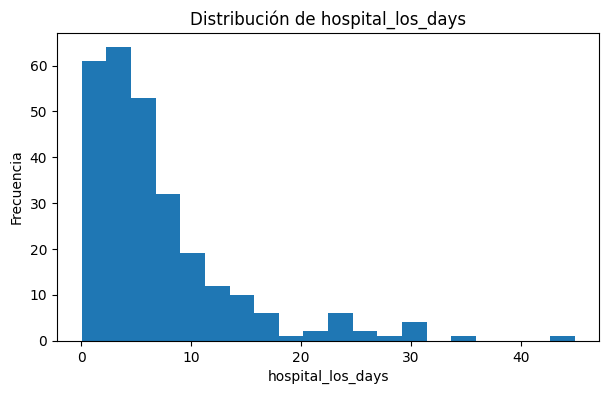

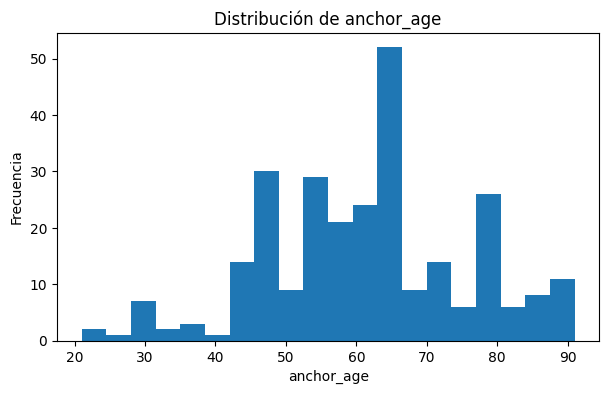

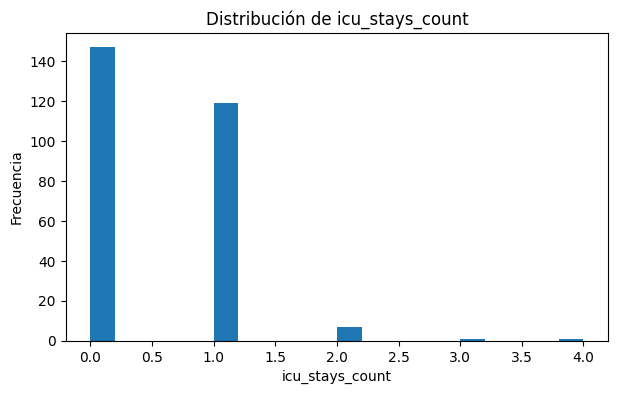

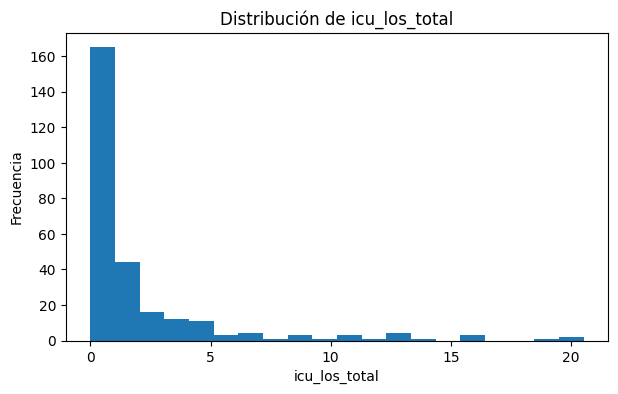

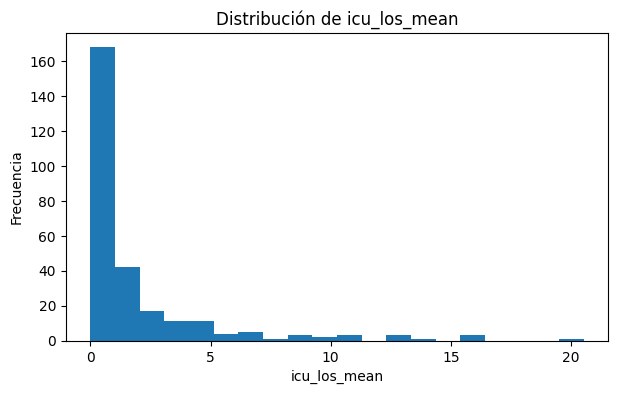

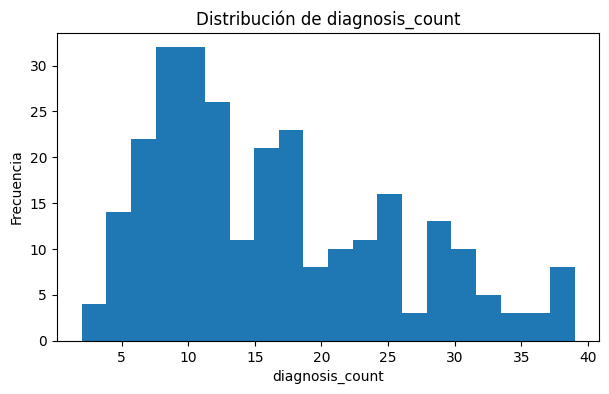

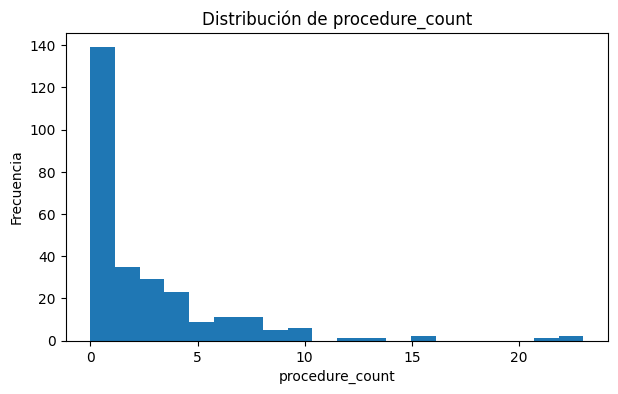

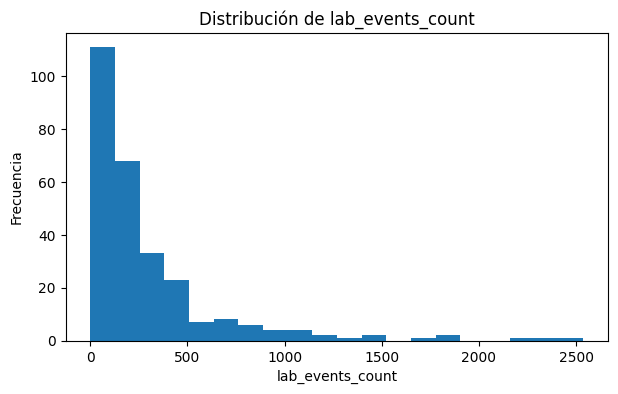

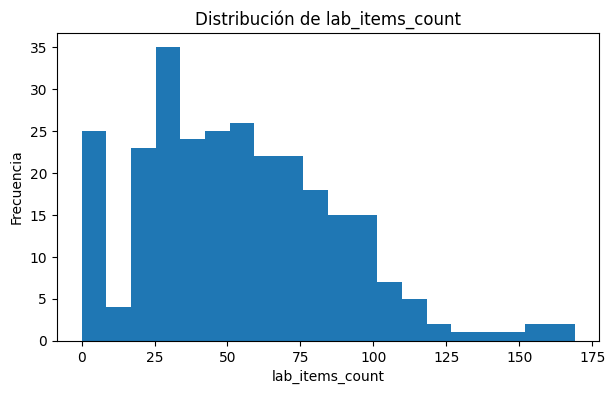

In [ ]:
for col in numeric_vars:
    plt.figure(figsize=(7, 4))
    plt.hist(df_model[col], bins=20)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

In [ ]:
df_model["long_stay"].value_counts()

,count
long_stay,
0,184
1,91


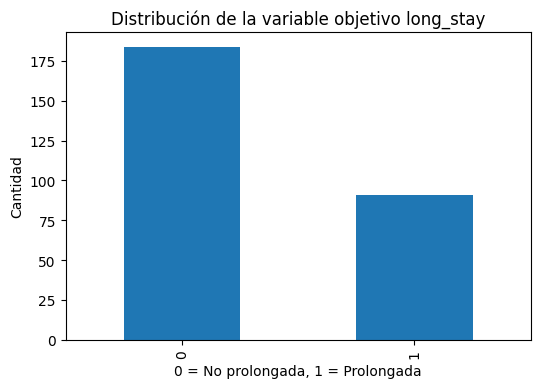

In [ ]:
plt.figure(figsize=(6, 4))
df_model["long_stay"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribución de la variable objetivo long_stay")
plt.xlabel("0 = No prolongada, 1 = Prolongada")
plt.ylabel("Cantidad")
plt.show()

In [ ]:
df_model[numeric_vars].describe()

,hospital_los_days,anchor_age,icu_stays_count,icu_los_total,icu_los_mean,diagnosis_count,procedure_count,lab_events_count,lab_items_count
count,275.000000,275.000000,275.000000,275.000000,275.000000,275.000000,275.000000,275.000000,275.000000
mean,6.875530,61.043636,0.509091,1.873138,1.712052,16.385455,2.625455,288.389091,54.276364
std,6.733832,14.440600,0.606315,3.630192,3.220250,9.014413,3.559926,390.057021,33.597391
min,0.046528,21.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000
25%,2.692014,52.500000,0.000000,0.000000,0.000000,9.000000,0.000000,63.000000,30.000000
50%,4.852778,60.000000,0.000000,0.000000,0.000000,14.000000,1.000000,163.000000,51.000000
75%,8.768403,70.000000,1.000000,1.992894,1.978556,23.000000,4.000000,350.500000,75.500000
max,44.927778,91.000000,4.000000,20.528681,20.528681,39.000000,23.000000,2538.000000,169.000000


### 16. Análisis de correlaciones

In [ ]:
corr_vars = [
    "long_stay",
    "hospital_los_days",
    "anchor_age",
    "has_ed_record",
    "hospital_expire_flag",
    "has_dod",
    "icu_stays_count",
    "icu_los_total",
    "icu_los_mean",
    "diagnosis_count",
    "procedure_count",
    "lab_events_count",
    "lab_items_count"
]

In [ ]:
corr_matrix = df_model[corr_vars].corr()
corr_matrix

,long_stay,hospital_los_days,anchor_age,has_ed_record,hospital_expire_flag,has_dod,icu_stays_count,icu_los_total,icu_los_mean,diagnosis_count,procedure_count,lab_events_count,lab_items_count
long_stay,1.000000,0.747581,0.010202,-0.101694,0.103330,0.190267,0.340589,0.463501,0.455767,0.412189,0.511261,0.604545,0.564772
hospital_los_days,0.747581,1.000000,-0.027647,-0.084294,0.144360,0.162962,0.414539,0.648517,0.569826,0.509814,0.676308,0.821487,0.650589
anchor_age,0.010202,-0.027647,1.000000,-0.067691,0.124804,0.113890,0.056644,0.038392,0.035888,0.212192,-0.091973,0.010175,0.023753
has_ed_record,-0.101694,-0.084294,-0.067691,1.000000,-0.065233,0.060867,-0.148017,-0.067599,-0.045859,0.116899,-0.196479,-0.084452,-0.025051
hospital_expire_flag,0.103330,0.144360,0.124804,-0.065233,1.000000,0.310388,0.327120,0.399715,0.402062,0.290462,0.246125,0.301388,0.312679
has_dod,0.190267,0.162962,0.113890,0.060867,0.310388,1.000000,-0.042659,0.061690,0.075268,0.206487,0.026594,0.169345,0.092867
icu_stays_count,0.340589,0.414539,0.056644,-0.148017,0.327120,-0.042659,1.000000,0.618274,0.514833,0.235740,0.442055,0.361951,0.439360
icu_los_total,0.463501,0.648517,0.038392,-0.067599,0.399715,0.061690,0.618274,1.000000,0.943712,0.469548,0.716831,0.667333,0.557624
icu_los_mean,0.455767,0.569826,0.035888,-0.045859,0.402062,0.075268,0.514833,0.943712,1.000000,0.449447,0.686970,0.643048,0.544439
diagnosis_count,0.412189,0.509814,0.212192,0.116899,0.290462,0.206487,0.235740,0.469548,0.449447,1.000000,0.404500,0.580086,0.591594


In [ ]:
corr_matrix["long_stay"].sort_values(ascending=False)

,long_stay
long_stay,1.000000
hospital_los_days,0.747581
lab_events_count,0.604545
lab_items_count,0.564772
procedure_count,0.511261
icu_los_total,0.463501
icu_los_mean,0.455767
diagnosis_count,0.412189
icu_stays_count,0.340589
has_dod,0.190267


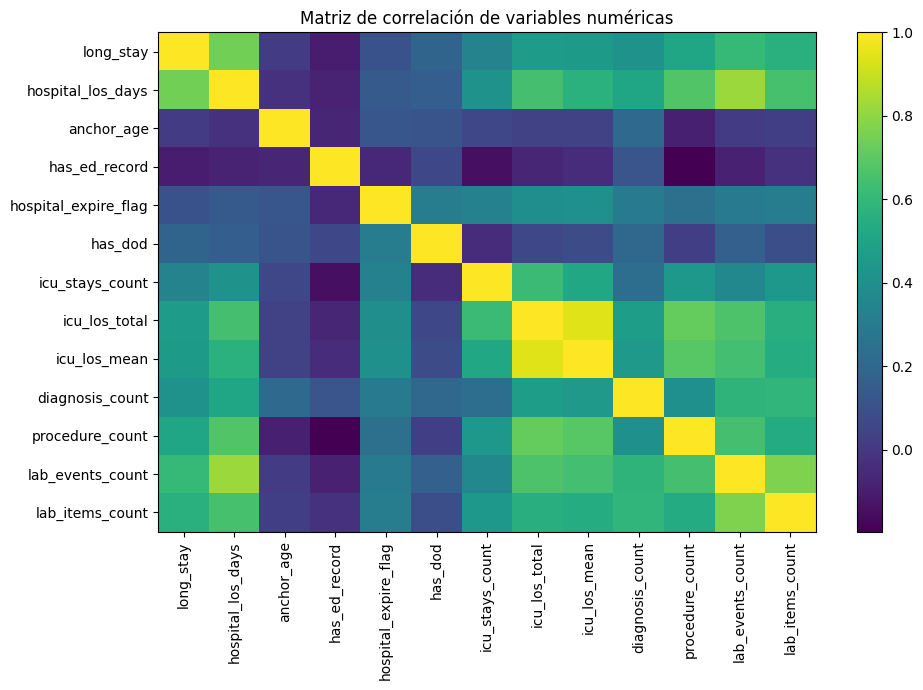

In [ ]:
plt.figure(figsize=(10, 7))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Matriz de correlación de variables numéricas")
plt.tight_layout()
plt.show()

### 17. Detección de outliers
Usaremos el método IQR.

In [ ]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    return lower_bound, upper_bound, len(outliers)

In [ ]:
outlier_vars = [
    "hospital_los_days",
    "anchor_age",
    "icu_los_total",
    "diagnosis_count",
    "procedure_count",
    "lab_events_count",
    "lab_items_count"
]

In [ ]:
outlier_results = []

for col in outlier_vars:
    lower, upper, count = detect_outliers_iqr(df_model, col)
    outlier_results.append({
        "variable": col,
        "limite_inferior": lower,
        "limite_superior": upper,
        "cantidad_outliers": count,
        "porcentaje_outliers": (count / len(df_model)) * 100
    })

outlier_summary = pd.DataFrame(outlier_results)
outlier_summary

,variable,limite_inferior,limite_superior,cantidad_outliers,porcentaje_outliers
0,hospital_los_days,-6.422569,17.882986,18,6.545455
1,anchor_age,26.250000,96.250000,3,1.090909
2,icu_los_total,-2.989340,4.982234,30,10.909091
3,diagnosis_count,-12.000000,44.000000,0,0.000000
4,procedure_count,-6.000000,10.000000,7,2.545455
5,lab_events_count,-368.250000,781.750000,24,8.727273
6,lab_items_count,-38.250000,143.750000,5,1.818182


## 18. Visualización de outliers

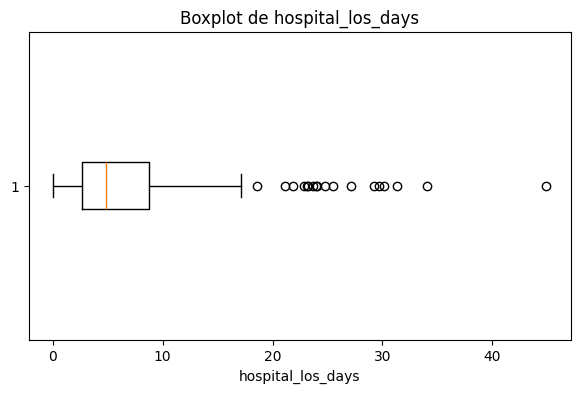

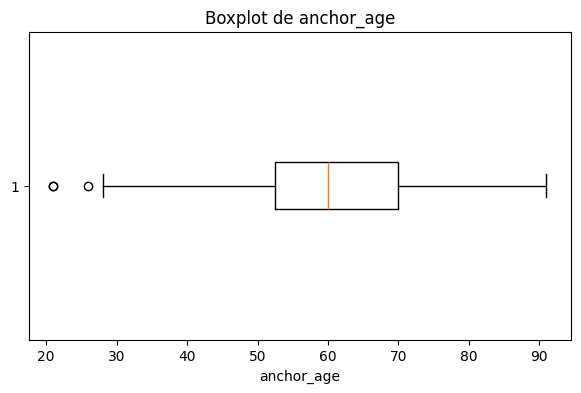

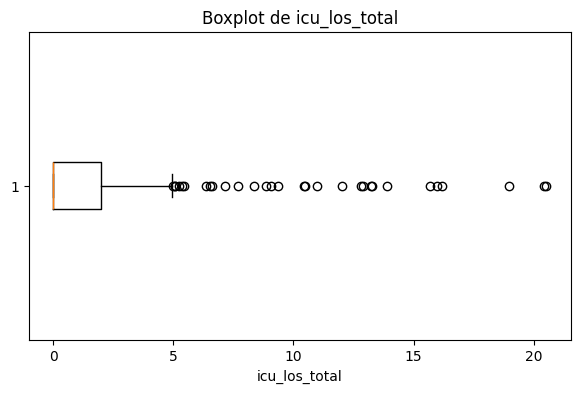

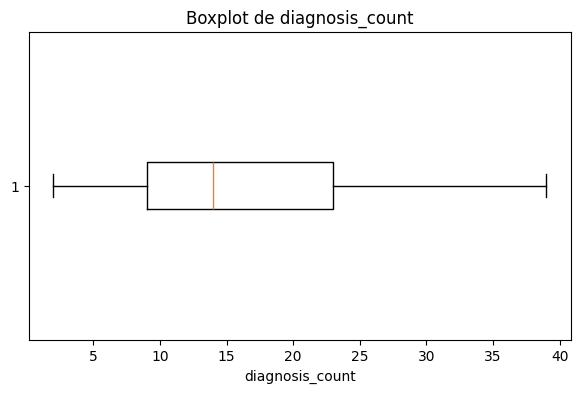

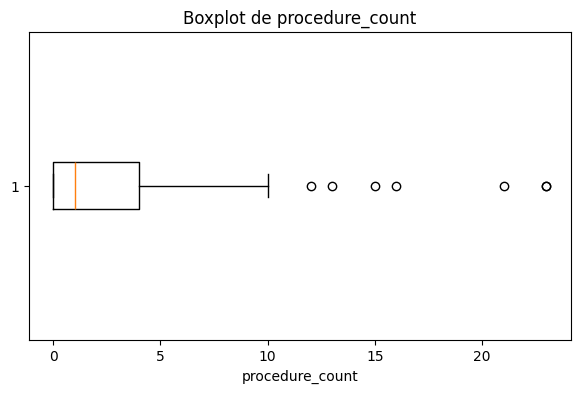

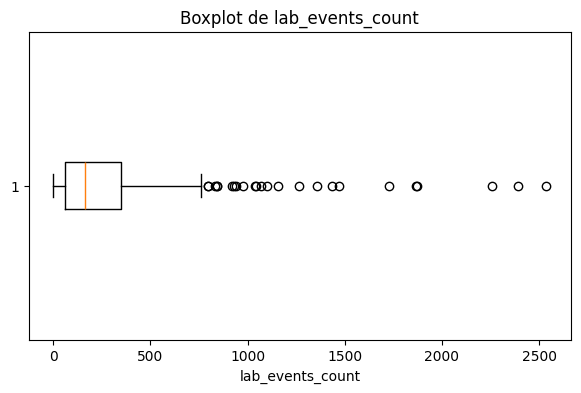

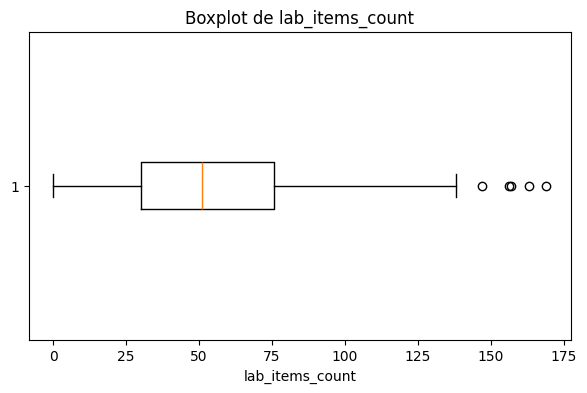

In [ ]:
for col in outlier_vars:
    plt.figure(figsize=(7, 4))
    plt.boxplot(df_model[col].dropna(), vert=False)
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.show()

## 19. Decisión sobre outliers
Para esta fase EDA, dejamos los outliers en el dataset, pero los documentamos.

In [ ]:
df_model_clean = df_model.copy()

Más adelante, en Data Preparation, se puede decidir si aplicar transformación logarítmica o winsorización.

Por ahora seguimos con una revisión final de nulos del dataset consolidado:

In [ ]:
df_model_clean.isnull().sum().sort_values(ascending=False)

,0
deathtime,260
edouttime,93
edregtime,93
subject_id,0
dischtime,0
admission_type,0
admittime,0
hadm_id,0
admission_location,0
admit_provider_id,0


### 20. Seleccionar columnas finales

In [ ]:
final_columns = [
    "subject_id",
    "hadm_id",
    "gender",
    "anchor_age",
    "admission_type",
    "admission_location",
    "discharge_location",
    "insurance",
    "language",
    "marital_status",
    "race",
    "hospital_expire_flag",
    "has_ed_record",
    "has_dod",
    "hospital_los_days",
    "icu_stays_count",
    "icu_los_total",
    "icu_los_mean",
    "diagnosis_count",
    "procedure_count",
    "lab_events_count",
    "lab_items_count",
    "long_stay"
]

df_final = df_model_clean[final_columns].copy()

### 21. Revisar dataset final

In [ ]:
df_final.head()

,subject_id,hadm_id,gender,anchor_age,admission_type,admission_location,discharge_location,insurance,language,marital_status,...,has_dod,hospital_los_days,icu_stays_count,icu_los_total,icu_los_mean,diagnosis_count,procedure_count,lab_events_count,lab_items_count,long_stay
0,10004235,24181354,M,47,URGENT,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicaid,ENGLISH,SINGLE,...,0,8.975000,1.0,4.952106,4.952106,26,5.0,843.0,95.0,1
1,10009628,25926192,M,58,URGENT,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicaid,?,MARRIED,...,0,7.841667,1.0,2.280752,2.280752,8,3.0,387.0,70.0,1
2,10018081,23983182,M,79,URGENT,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicare,ENGLISH,MARRIED,...,1,5.731250,0.0,0.000000,0.000000,19,2.0,259.0,66.0,0
3,10006053,22942076,M,52,URGENT,TRANSFER FROM HOSPITAL,DIED,Medicaid,ENGLISH,Unknown,...,1,1.736806,2.0,1.775093,0.887546,10,3.0,313.0,104.0,0
4,10031404,21606243,F,82,URGENT,TRANSFER FROM HOSPITAL,HOME,Other,ENGLISH,WIDOWED,...,0,2.090972,1.0,1.206481,1.206481,15,1.0,57.0,35.0,0


In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   subject_id            275 non-null    int64  
 1   hadm_id               275 non-null    int64  
 2   gender                275 non-null    object 
 3   anchor_age            275 non-null    int64  
 4   admission_type        275 non-null    object 
 5   admission_location    275 non-null    object 
 6   discharge_location    275 non-null    object 
 7   insurance             275 non-null    object 
 8   language              275 non-null    object 
 9   marital_status        275 non-null    object 
 10  race                  275 non-null    object 
 11  hospital_expire_flag  275 non-null    int64  
 12  has_ed_record         275 non-null    int64  
 13  has_dod               275 non-null    int64  
 14  hospital_los_days     275 non-null    float64
 15  icu_stays_count       2

In [ ]:
df_final.isnull().sum()

,0
subject_id,0
hadm_id,0
gender,0
anchor_age,0
admission_type,0
admission_location,0
discharge_location,0
insurance,0
language,0
marital_status,0


In [ ]:
df_final.shape

(275, 23)

### 22. Guardar nuevo CSV

In [ ]:
df_final.to_csv("mimic_iv_eda_dataset_final.csv", index=False)